In [149]:
# Aluno: Nicholas Barbosa e Costa
# Matrícula: 95667

from torch.utils.data import DataLoader, random_split #empacotamento de dados e divisão do dataset
import torchvision  

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchinfo import summary

from torch.utils.tensorboard import SummaryWriter

import torch.optim 

from tqdm import tqdm

import copy
  
from datetime import datetime

import PIL

import random

SEED = 95667


np.random.seed(SEED)
torch.manual_seed(SEED)

# Se estiver usando GPU Apple (MPS):
torch.mps.manual_seed(SEED)

# Dados

## Caminhos

In [150]:
datasets_path     = '/Users/nicholasbarbosa/Mestrado/inf692/atividade-curta-6/datasets/'
models_path       = '/Users/nicholasbarbosa/Mestrado/inf692/atividade-curta-6/models/'
tensorboard_path  = '/Users/nicholasbarbosa/Mestrado/inf692/atividade-curta-6/Tensorboard/2026_1/lenet5/'

## Dataloader

In [151]:
def my_imshow(img, dataset, numImages=10):
  
    if dataset == 'cifar10' : 
        img = img / 2 + 0.5     # unnormalize
    
    img = torchvision.utils.make_grid(img[:numImages],nrow=numImages//2)
    
    npimg = img.numpy()    
    npimg = np.transpose(npimg, (1, 2, 0))
    
    plt.axis('off')
    plt.imshow(npimg)
    plt.show()

def show_images(data_loader, dataset, numImages=10) :
    print(f"Train samples, {data_loader['train']['length']}")
    # get some random training images
    dataiter = iter(data_loader['train']['data']) # cria um iterador para o DataLoader de treino
    images = next(dataiter)[0] # obtém o próximo lote de imagens do iterador, mas retorna apenas as imagens (0)
    my_imshow(images, dataset, numImages) 

    print(f"Val samples, {data_loader['val']['length']}")
    # get some random val images
    dataiter = iter(data_loader['val']['data'])
    images = next(dataiter)[0]
    my_imshow(images, dataset, numImages)
    
    print(f"Test samples, {data_loader['test']['length']}")
    # get some random training images
    dataiter = iter(data_loader['test']['data'])
    images = next(dataiter)[0]
    my_imshow(images, dataset, numImages)

def get_data_cifar10 ( batch_size , show_image=False, numImages=10 ) :
  
    # define a transformação para redimensionar, converter para tensor e normalizar as imagens quando forem carregadas
    my_transform = torchvision.transforms.Compose([
                            torchvision.transforms.Resize(32),
                            torchvision.transforms.ToTensor(),
                            torchvision.transforms.Normalize(mean=[0.5],std=[0.5])
                                    ])

    # retorna um objeto onde cada posicao eh uma tupla (imagem, label). a imagem ja esta tansformada
    # pega os dados de teste
    test_dataset = torchvision.datasets.CIFAR10(
                                root=f'{datasets_path}/test/',
                                train=False, 
                                transform=my_transform, 
                                download=False
                                )
    # pega os dados de treino
    full_train_dataset = torchvision.datasets.CIFAR10(
                                root=f'{datasets_path}/train/', 
                                train=True, 
                                transform=my_transform, 
                                download=False
                                )

    train_ratio = 0.8
    train_size = int(train_ratio * len(full_train_dataset))
    val_size = len(full_train_dataset) - train_size

    # cria os dados de treino e validacao a partir dos dados de treino
    train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])
    
    # iterador que retorna os dados em batchs. por exemplo, cada acesso ao data_loader retorna 256 imagens
    train_loader = DataLoader(train_dataset, 
                            batch_size=batch_size,
                            shuffle=True # embaralha os dados a cada época
                            )
    val_loader = DataLoader(val_dataset, 
                            batch_size=batch_size,
                            shuffle=False
                            )
    test_loader = DataLoader(test_dataset, 
                            batch_size=batch_size,
                            shuffle=False
                            )

    data_loader = {
        'train': {'data':train_loader, 'length':len(train_dataset)},
        'test' : {'data':test_loader , 'length':len(test_dataset) },
        'val'  : {'data':val_loader  , 'length':len(val_dataset)  },
        'name' : 'cifar10',
        'n_channels' : 3,
        'num_classes' : 10
    }
    
    if show_image :
        show_images(data_loader, data_loader['name'], numImages)
    
    return data_loader


def get_data_mnist ( batch_size , show_image=False, numImages=10 ) :
  
    # retorna um objeto onde cada posicao eh uma tupla (imagem, label). a imagem ja esta tansformada
    # pega os dados de teste
    full_train_dataset = torchvision.datasets.mnist.MNIST(
                            root=f'{datasets_path}/train/', 
                            train=True, 
                            transform=torchvision.transforms.ToTensor(), 
                            download=False
                            )
    test_dataset = torchvision.datasets.mnist.MNIST(
                            root=f'{datasets_path}/test/',
                            train=False, 
                            transform=torchvision.transforms.ToTensor(), 
                            download=False
                            )

    train_ratio = 0.8
    train_size = int(train_ratio * len(full_train_dataset))
    val_size = len(full_train_dataset) - train_size 

    train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    data_loader = {
        'train': {'data':train_loader, 'length':len(train_dataset)},
        'test' : {'data':test_loader , 'length':len(test_dataset) },
        'val'  : {'data':val_loader  , 'length':len(val_dataset)  },
        'name' : 'mnist',
        'n_channels' : 1,
        'num_classes' : 10
    }
    
    if show_image :
        show_images(data_loader, data_loader['name'], numImages)
    
    return data_loader

def get_data_alexnet ( batch_size , show_image=False, numImages=10 ) :
    my_transform = torchvision.transforms.Compose([
                    torchvision.transforms.Resize(227),
                    torchvision.transforms.ToTensor(),
                    torchvision.transforms.Normalize(mean=[0.5],std=[0.5])
                    ])
    
    test_dataset = torchvision.datasets.CIFAR10(
                                root=f'{datasets_path}/test/',
                                train=False, 
                                transform=my_transform, 
                                download=False
                                )
    
    full_train_dataset = torchvision.datasets.CIFAR10(
                            root=f'{datasets_path}/train/',
                            train=True, 
                            transform=my_transform, 
                            download=False
                            )
    
    train_ratio = 0.8
    train_size = int(train_ratio * len(full_train_dataset))
    val_size = len(full_train_dataset) - train_size

    train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])
    
    train_loader = DataLoader(train_dataset, 
                            batch_size=batch_size,
                            shuffle=True # embaralha os dados a cada época
                            )
    val_loader = DataLoader(val_dataset, 
                            batch_size=batch_size,
                            shuffle=False
                            )
    test_loader = DataLoader(test_dataset, 
                            batch_size=batch_size,
                            shuffle=False
                            )
    
    data_loader = {
        'train': {'data':train_loader, 'length':len(train_dataset)},
        'test' : {'data':test_loader , 'length':len(test_dataset) },
        'val'  : {'data':val_loader  , 'length':len(val_dataset)  },
        'name' : 'cifar10',
        'n_channels' : 3,
        'num_classes' : 10
    }
    
    if show_image :
        show_images(data_loader, data_loader['name'], numImages)
    
    return data_loader

Train samples, 48000


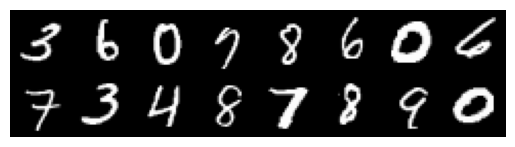

Val samples, 12000


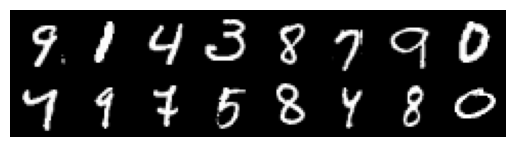

Test samples, 10000


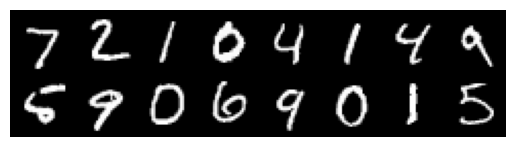

In [152]:
get_data_mnist(batch_size=256, show_image=True, numImages=16);

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train samples, 40000


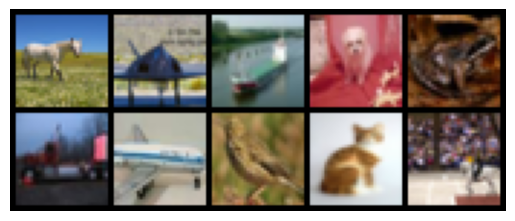

Val samples, 10000


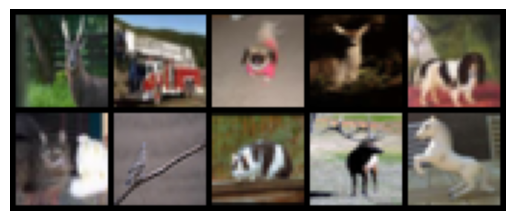

Test samples, 10000


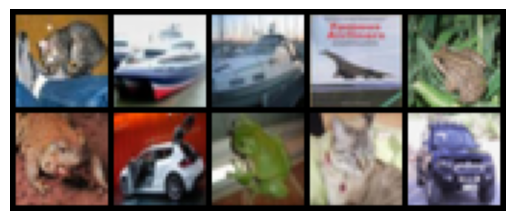

In [153]:
get_data_cifar10(batch_size=256, show_image=True, numImages=10);

Train samples, 40000


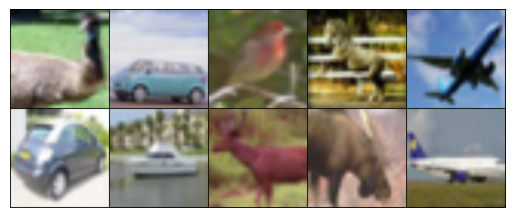

Val samples, 10000


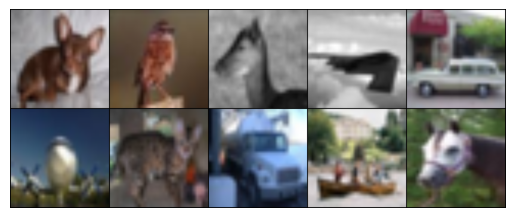

Test samples, 10000


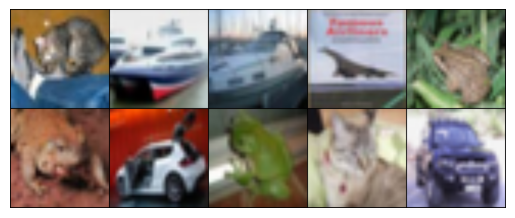

In [154]:
get_data_alexnet(batch_size=256, show_image=True, numImages=10);

# Rede

## Arquitetura

In [155]:
class LeNet(nn.Module) :
    def __init__(self, num_classes=10, in_channels=1):
        super(LeNet, self).__init__()
        self.c1 = nn.Conv2d(in_channels=in_channels, out_channels=6, 
                            kernel_size=(5,5), padding=2, stride=1)
        self.s2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.activationS2 = nn.Sigmoid()
        self.c3 = nn.Conv2d(in_channels=6, out_channels=16, 
                            kernel_size=(5,5), padding=0, stride=1)
        self.s4 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.activationS4 = nn.Sigmoid()
        self.c5 = nn.Conv2d(in_channels=16, out_channels=120, 
                            kernel_size=(5,5), padding=0, stride=2)
        self.activationC5 = nn.Sigmoid()
        self.f6 = nn.Linear(in_features=120, out_features=84)
        self.activationF6 = nn.Tanh()
        self.f = nn.Linear(in_features=84, out_features=num_classes)
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x, debug=False):
        # Convolutional
        if debug : print('Input',x.shape)
        y = self.c1(x)
        if debug : print('Outputs:')
        if debug : print('C1',y.shape)
        y = self.s2(y)
        if debug : print('S2',y.shape)
        y = self.activationS2(y)
        if debug : print('Activation S2',y.shape)
        y = self.c3(y)
        if debug : print('C3',y.shape)
        y = self.s4(y)
        if debug : print('S4',y.shape)
        y = self.activationS4(y)
        if debug : print('Activation S4',y.shape)
        # Flattening
        y = self.c5(y)
        if debug : print('C5',y.shape)
        y = self.activationC5(y)
        if debug : print('Activation C5',y.shape)
        y = y.view(y.shape[0], -1)
        if debug : print('Reshape C5',y.shape)
        # Fully Connected
        y = self.f6(y)
        if debug : print('F6',y.shape)
        y = self.activationF6(y)
        if debug : print('Activation F6',y.shape)
        y = self.f(y)
        if debug : print('F',y.shape)
        s = self.softmax(y)
        if debug : print('Softamx',s.shape)
        return y, s
    
class AlexNet(nn.Module) :
    def __init__(self, num_classes=10, in_channels=3, dropout_p=0.5):
        super(AlexNet, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=96, kernel_size=(11,11),stride=4),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(in_channels=96, out_channels=256, kernel_size=(5,5), padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(in_channels=256, out_channels=384, kernel_size=(3,3), padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=384, out_channels=384, kernel_size=(3,3), padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=384, out_channels=256, kernel_size=(3,3), padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),  
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(in_features=9216, out_features=4096) ,
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(in_features=4096, out_features=4096),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(in_features=4096, out_features=num_classes),
        )
        
        self.softmax = nn.LogSoftmax(dim=1)

       
    def forward(self, x, debug=False):  
        y = self.features(x)
        if debug : print('Features',y.shape)
        y = y.view(y.shape[0], -1)
        if debug : print('Flatten',y.shape)
        y = self.classifier(y)
        if debug : print('Classifier',y.shape)  
        s = self.softmax(y)
     
        return s

## Informações sobre a rede

In [156]:
if torch.backends.mps.is_available():
    my_device = torch.device("mps")
elif torch.cuda.is_available():
    my_device = torch.device("cuda:0")
else:
    my_device = torch.device("cpu")
    
print(f"Running on {my_device.type}.")

net = AlexNet(num_classes=10, in_channels=3)
net = net.to(my_device)

a = torch.rand( (1, 3, 227, 227) )

b = net( a.to(my_device), debug=True )

Running on mps.
Features torch.Size([1, 256, 6, 6])
Flatten torch.Size([1, 9216])
Classifier torch.Size([1, 10])


In [157]:

print(summary(net, input_size=(1, 3, 227, 227)))
del net, a, b

Layer (type:depth-idx)                   Output Shape              Param #
AlexNet                                  [1, 10]                   --
├─Sequential: 1-1                        [1, 256, 6, 6]            --
│    └─Conv2d: 2-1                       [1, 96, 55, 55]           34,944
│    └─ReLU: 2-2                         [1, 96, 55, 55]           --
│    └─MaxPool2d: 2-3                    [1, 96, 27, 27]           --
│    └─Conv2d: 2-4                       [1, 256, 27, 27]          614,656
│    └─ReLU: 2-5                         [1, 256, 27, 27]          --
│    └─MaxPool2d: 2-6                    [1, 256, 13, 13]          --
│    └─Conv2d: 2-7                       [1, 384, 13, 13]          885,120
│    └─ReLU: 2-8                         [1, 384, 13, 13]          --
│    └─Conv2d: 2-9                       [1, 384, 13, 13]          1,327,488
│    └─ReLU: 2-10                        [1, 384, 13, 13]          --
│    └─Conv2d: 2-11                      [1, 256, 13, 13]       

## Treinamento

In [158]:
def plot_histograms_tensorboard(writer, net, epoch):
    for name, param in net.named_parameters():
        if torch.isnan(param.data).any():
            print(f'NaN detectado em {name}')
            continue
        writer.add_histogram(f'Weight/{name}', param.data.cpu(), epoch)
        if param.grad is not None and not torch.isnan(param.grad).any():
            writer.add_histogram(f'Grad/{name}', param.grad.cpu(), epoch)


### Validação

In [159]:
def validate ( model , data , device='cpu', criterion=None, confusion_matrix_labels=None) :
    model.eval()
    correct = 0 # acumula o numero de predicoes corretas
    error = 0   # acumula o erro total do modelo, se for calculado

    label_cm = np.array([])
    predicted_cm = np.array([])
    
    for idx, (test_x, test_label) in enumerate(data['data']) : 
        # coloca os dados no mesmo dispositivo do modelo para fazer a predicao 
        test_x = test_x.to(device)
        test_label = test_label.to(device)

        # resultado retornado pelo modelo
        predict_y = model( test_x ).detach() # resultado do modelo sem calcular o gradiente, para economizar memoria
        # pega a classe com maior probabilidade como predicao do modelo
        predict_ys = torch.max( predict_y, axis=1 )[1]

        correct = correct + torch.sum(predict_ys == test_label) # acumula o numero de predicoes corretas

        if criterion != None:
            error = error + criterion( predict_y , test_label )

        # se for para calcular a matriz de confusão, salva as classes verdadeiras e preditas para depois calcular a matriz completa
        if confusion_matrix_labels != None :
            label_cm = np.concatenate((label_cm, test_label.cpu().numpy()))
            predicted_cm = np.concatenate((predicted_cm, predict_ys.cpu().numpy()))

    accuracy = correct*100./data['length']  # calcula a acurácia total do modelo no conjunto de dados

    if confusion_matrix_labels != None :
        cm = confusion_matrix(
                label_cm, 
                predicted_cm, 
                normalize='true'
            )
        cm = np.round(cm*100, 1)
        disp = ConfusionMatrixDisplay(cm, display_labels=confusion_matrix_labels)
        disp.plot(cmap='Blues')
        plt.title('Normalized Confusion Matrix')
        plt.show()

        cm = confusion_matrix(
                label_cm, 
                predicted_cm, 
            )
        disp = ConfusionMatrixDisplay(cm, display_labels=confusion_matrix_labels)
        disp.plot(cmap='Blues')
        plt.title('Confusion Matrix')
        plt.show()
    
    if criterion == None:
        return accuracy
    else :
        return accuracy, error

In [160]:
batch_size = 256

def train ( data_loader, epochs=100, lr=1e-1, prefix='', upper_bound=99.0, device='cpu',
           save=False, debug=False, plot_histograms=False, lambda_reg=0) :

    net = AlexNet( data_loader['num_classes'], data_loader['n_channels'] )
    net.to(device)

    # quais parâmetros do modelo devem ser otimizados e qual a taxa de aprendizado
    optimizer = torch.optim.SGD(net.parameters(), lr, momentum=0.9, weight_decay=lambda_reg)

    loss = nn.NLLLoss()

    # nome do experimento para o tensorboard
    now = datetime.now()
    suffix = now.strftime("%Y%m%d_%H%M%S")
    prefix = prefix + '-' + suffix if prefix != '' else suffix

    # escreve os logs no tensorboard
    writer = SummaryWriter( log_dir=tensorboard_path+prefix )
    writer.add_graph(net, next(iter(data_loader['train']['data']))[0].to(device))

    accuracies = []         # guarda acurácia de cada época para plotar depois
    max_accuracy = -1.0     # melhor acurácia obtida durante o treinamento

    dataset_size = data_loader['train']['length']

    for epoch in tqdm( range(epochs) , desc='Training epochs...' ) :
        net.train()  
        for idx, (train_x, train_label) in enumerate(data_loader['train']['data']):
            # move o tensor para a gpu
            train_x = train_x.to(device)
            train_label = train_label.to(device)

            optimizer.zero_grad() # zera os gradientes acumulados do passo anterior

            predict_y = net( train_x ) # saida do modelo

            # Loss:
            error = loss( predict_y , train_label.long() )

            # salva o valor da loss no tensorboard
            writer.add_scalar( 'Loss/train', error, 
                            idx+( epoch*(dataset_size//batch_size) ) )



            error.backward() # calcula os gradientes de todos os pesos
            optimizer.step() # atualiza os pesos com base nos gradientes calculados

            # Accuracy:
            predict_ys = torch.max( predict_y, axis=1 )[1]      # retorna a classe com a maior probabilidade prevista pelo modelo
            correct    = torch.sum(predict_ys == train_label)   # conta quantas previsões estão corretas comparando com as labels verdadeiras

            writer.add_scalar( 'Accuracy/train', correct/train_x.size(0)*100, 
                            idx+( epoch*(dataset_size//batch_size) ) )

            if debug and idx % 10 == 0 :
                print(f'idx: {idx}, _error: {error}')

        # salva os histogramas dos pesos e gradientes no tensorboard para visualização
        if plot_histograms : 
            plot_histograms_tensorboard(writer, net, epoch)
        
        # valida o modelo no conjunto de validação e salva a acurácia
        accuracy_val, error_val = validate(net, data_loader['val'], device=device, criterion=loss)
        
        # salva a acurácia de validação para plotar depois e no tensorboard
        accuracies.append(accuracy_val.cpu())
        writer.add_scalar( 'Accuracy/val', accuracy_val, epoch )
    
        # guarda a maior acurácia e salva o modelo correspondente
        if accuracy_val > max_accuracy:
            best_model = copy.deepcopy(net)
            max_accuracy = accuracy_val
            print(f'Saving Best Model with Accuracy: {max_accuracy:3.4f}')
            
        print( f'Epoch: {epoch+1:3d} | Accuracy : {accuracy_val:3.4f}%' ) # printa acurácia de validação a cada época

        # se a acurácia de validação ultrapassar o limite definido, interrompe o treinamento
        if accuracy_val > upper_bound :
            break
   
    # salva o melhor modelo encontrado durante o treinamento
    if save : 
        path = f'{models_path}-{prefix}-{max_accuracy:.2f}.pkl'
        torch.save(best_model.state_dict(), path)
        print('Model saved in:',path)
  
    # plota a acurácia de validação ao longo das épocas
    plt.plot(accuracies)

    writer.flush()
    writer.close()
    
    return best_model

# Execução

## Treina

Train samples, 40000


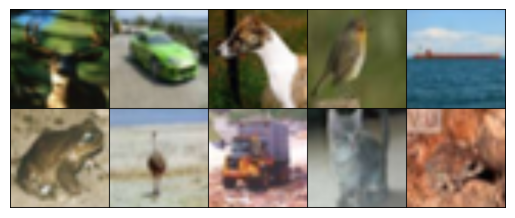

Val samples, 10000


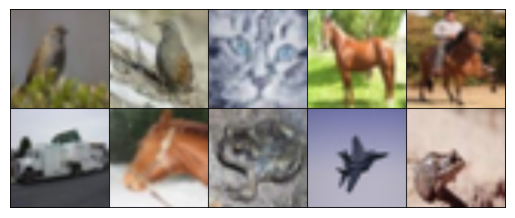

Test samples, 10000


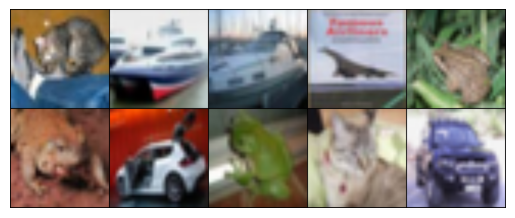

In [161]:
if torch.backends.mps.is_available():
    my_device = torch.device("mps")
elif torch.cuda.is_available():
    my_device = torch.device("cuda:0")
else:
    my_device = torch.device("cpu")

epochs = 20
dataset = 'cifar10' 
# dataset = 'mnist' 
lr = 1e-2
lambda_reg = 0

if dataset == 'mnist' :
    batch_size = 256
    data_loader = get_data_mnist(batch_size, show_image=True)
elif dataset == 'cifar10' :
    batch_size = 256
    data_loader = get_data_alexnet(batch_size, show_image=True)
else :
    print('Dataset loader not implemented.')
    

prefix = 'AlexNet-{}-e-{}-lr-{}'.format(dataset, epochs, lr)

Running on mps.


Training epochs...:   5%|▌         | 1/20 [09:00<2:51:11, 540.61s/it]

Saving Best Model with Accuracy: 17.9800
Epoch:   1 | Accuracy : 17.9800%


Training epochs...:  10%|█         | 2/20 [19:03<2:53:14, 577.45s/it]

Saving Best Model with Accuracy: 30.9000
Epoch:   2 | Accuracy : 30.9000%


...

Training epochs...:  95%|█████████▌| 19/20 [3:29:52<13:20, 800.62s/it]

Epoch:  19 | Accuracy : 81.1300%


Training epochs...: 100%|██████████| 20/20 [3:41:27<00:00, 664.39s/it]

Epoch:  20 | Accuracy : 81.0900%


Model saved in: /Users/nicholasbarbosa/Mestrado/inf692/atividade-curta-6/models/-AlexNet-cifar10-e-20-lr-0.01-20260513_100303-81.31.pkl


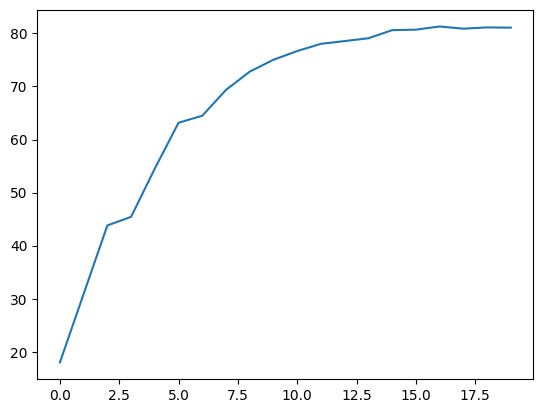

In [162]:
print(f"Running on {my_device.type}.")

net = train( data_loader=data_loader, epochs=epochs, lr=lr, prefix=prefix , upper_bound=100, device=my_device,
            save=True, debug=False, plot_histograms=True, lambda_reg=lambda_reg )

# Carregar Rede de arquivo

In [168]:

path = '/Users/nicholasbarbosa/Mestrado/inf692/atividade-curta-6/models/-AlexNet-cifar10-e-20-lr-0.01-20260513_100303-81.31.pkl'
n_channels = 3

if torch.backends.mps.is_available():
    my_device = torch.device("mps")
elif torch.cuda.is_available():
    my_device = torch.device("cuda:0")
else:
    my_device = torch.device("cpu")


def load_AlexNet ( device , path ) :
    net = AlexNet(num_classes=10, in_channels=n_channels)
    net = net.to(device)
    net.load_state_dict(torch.load(path, weights_only=False))
    net.eval()
    return net

net = load_AlexNet(my_device, path)





# Carregar dado do CIFAR10 e inferir

Sample: 8149


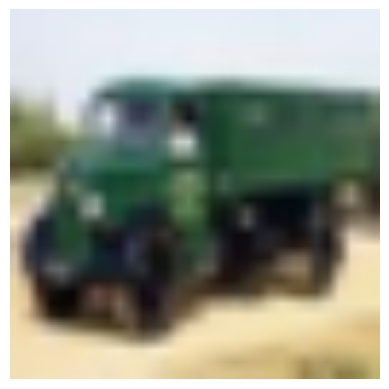


Predicted clas: 9 
Classifier confidence: -0.00% 
True label: 9


In [169]:
def sample_and_predict ( data_loader ) :

    test_dataset = data_loader['test']['data'].dataset  # pega o dataset de teste para acessar as imagens individuais
    idx = np.random.randint(0, len(test_dataset) - 1)   # gera um indice aleatorio para escolher uma amostra do dataset de teste
    img, label = test_dataset[idx]                      # pega a imagem e a label correspondente ao indice escolhido
    
    x = img.unsqueeze_(0)   # insere uma dimensão extra para representar o batch 

    x = x.to(my_device)     # coloca a imagem no mesmo dispositivo do modelo para fazer a predicao

    y = net ( x )                   # pega a saída de probabilidades do modelo para a imagem de teste
    confidence = torch.max(y, 1)[0] # pega a maior probabilidade prevista pelo modelo como confiança da predicao
    prediction = torch.max(y, 1)[1] # pega qual a classe que teve a maior probabilidade 

    print( 'Sample: {}'.format(idx) )
    
    img = img.squeeze_(0) # remove a dimensão de batch para mostrar a imagem original

    if dataset=='cifar10':
        img_show = img * 0.5 + 0.5
        plt.imshow(img_show.permute(1, 2, 0))
        
    else :
        img_show = img.squeeze()  
        img_show = img_show * 0.5 + 0.5 # unnormalizar a imagem 
        
        plt.imshow(img_show, cmap='gray')
        
    plt.axis('off')
    plt.show()

    confidence = confidence.data.cpu().numpy()[0]
    prediction = prediction.data.cpu().numpy()[0]

    return prediction, confidence, label

prediction, confidence, label = sample_and_predict(data_loader)
print( f'\nPredicted clas: {prediction} \nClassifier confidence: {confidence*100:4.2f}% \nTrue label: {label}' )


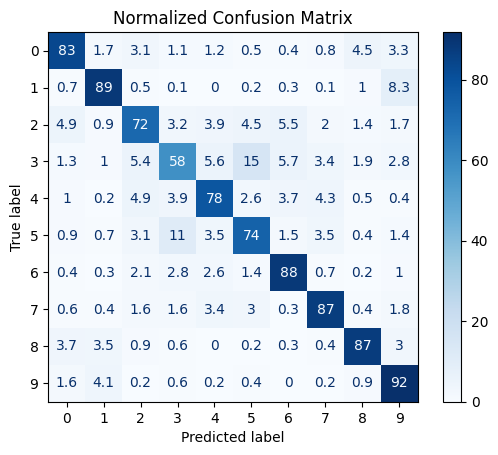

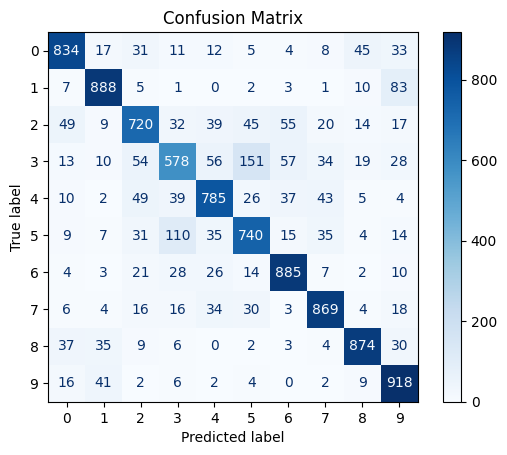

A acurácia do modelo treinado no conjunto de teste é: 80.91% 


In [170]:
accuracy_test = validate ( net , 
                          data_loader['test'] , 
                          device=my_device, 
                          confusion_matrix_labels=['0','1','2','3','4','5','6','7','8','9']
                         )
print(f"A acurácia do modelo treinado no conjunto de teste é: {accuracy_test:.2f}% ")